In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")

In [2]:
n = 500

A = np.random.normal(loc=50, scale=10, size=n)

B_raw = np.random.exponential(scale=1.0, size=n)
B = 100 * (B_raw - B_raw.min()) / (B_raw.max() - B_raw.min())

C1 = np.random.normal(loc=30, scale=5, size=n//2)
C2 = np.random.normal(loc=70, scale=5, size=n//2)
C = np.concatenate([C1, C2])

def summarize(data):
    mean = np.mean(data)
    median = np.median(data)
    
    # Mode (approximate by rounding to 2 decimals first)
    rounded = np.round(data, 2)
    mode = stats.mode(rounded, keepdims=False).mode
    
    std = np.std(data, ddof=1)
    var = np.var(data, ddof=1)
    
    q75, q25 = np.percentile(data, [75, 25])
    iqr = q75 - q25
    
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)
    
    return [mean, median, mode, std, var, iqr, skew, kurt]

summary = pd.DataFrame(
    [summarize(A), summarize(B), summarize(C)],
    columns=["Mean","Median","Mode","Std Dev","Variance","IQR","Skewness","Kurtosis"],
    index=["Dataset A (Normal)", "Dataset B (Right-skewed)", "Dataset C (Bimodal)"]
)

summary = summary.round(2)

print(summary)

"""
The mean and median look similar, especially for Dataset A and C
Skewness, spread, and mode show the differences, like skewed data in B and two peaks in C
"""

                           Mean  Median   Mode  Std Dev  Variance    IQR  \
Dataset A (Normal)        50.07   50.13  34.85     9.81     96.29  13.37   
Dataset B (Right-skewed)  16.17   11.29   0.14    15.99    255.64  18.65   
Dataset C (Bimodal)       50.33   49.53  24.89    20.30    412.02  39.01   

                          Skewness  Kurtosis  
Dataset A (Normal)            0.18      0.26  
Dataset B (Right-skewed)      1.77      3.98  
Dataset C (Bimodal)           0.01     -1.76  


'\nThe mean and median look similar, especially for Dataset A and C\nSkewness, spread, and mode show the differences, like skewed data in B and two peaks in C\n'

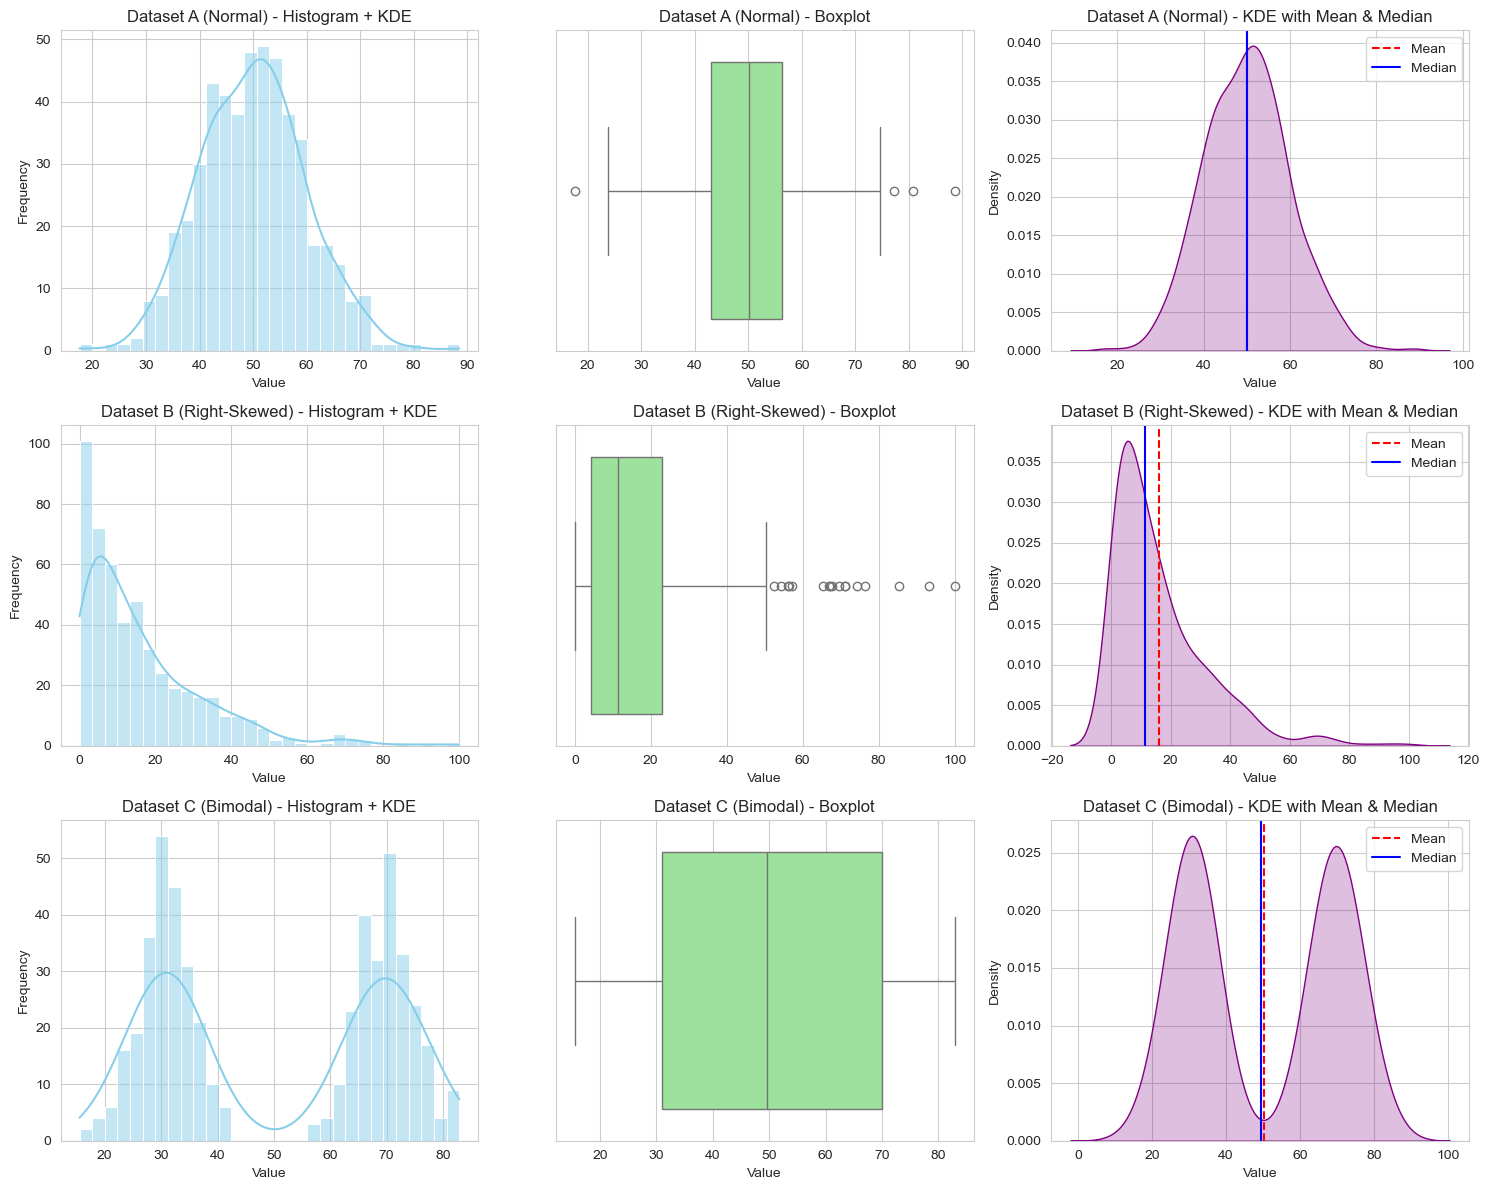

'\nThe mean and median differ the most in Dataset B\nThis happens because the distribution is right-skewed, with a long tail pulling the mean to the right\n'

In [3]:
datasets = [A, B, C]
names = ["Dataset A (Normal)", "Dataset B (Right-Skewed)", "Dataset C (Bimodal)"]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, data in enumerate(datasets):
    mean = np.mean(data)
    median = np.median(data)

    sns.histplot(data, bins=30, kde=True, ax=axes[i, 0], color="skyblue")
    axes[i, 0].set_title(f"{names[i]} - Histogram + KDE")
    axes[i, 0].set_xlabel("Value")
    axes[i, 0].set_ylabel("Frequency")

    sns.boxplot(x=data, ax=axes[i, 1], color="lightgreen")
    axes[i, 1].set_title(f"{names[i]} - Boxplot")
    axes[i, 1].set_xlabel("Value")

    sns.kdeplot(data, ax=axes[i, 2], color="purple", fill=True)
    axes[i, 2].axvline(mean, color="red", linestyle="--", label="Mean")
    axes[i, 2].axvline(median, color="blue", linestyle="-", label="Median")
    axes[i, 2].set_title(f"{names[i]} - KDE with Mean & Median")
    axes[i, 2].set_xlabel("Value")
    axes[i, 2].set_ylabel("Density")
    axes[i, 2].legend()

plt.tight_layout()
plt.show()

"""
The mean and median differ the most in Dataset B
This happens because the distribution is right-skewed, with a long tail pulling the mean to the right
"""

                        Mean  Median   Mode  Std Dev  Variance    IQR  \
Original A             50.07   50.13  34.85     9.81     96.29  13.37   
Modified A (Outliers)  57.17   50.13  34.85    74.38   5532.48  13.37   

                       Skewness  Kurtosis  
Original A                 0.18      0.26  
Modified A (Outliers)      9.70     94.18  


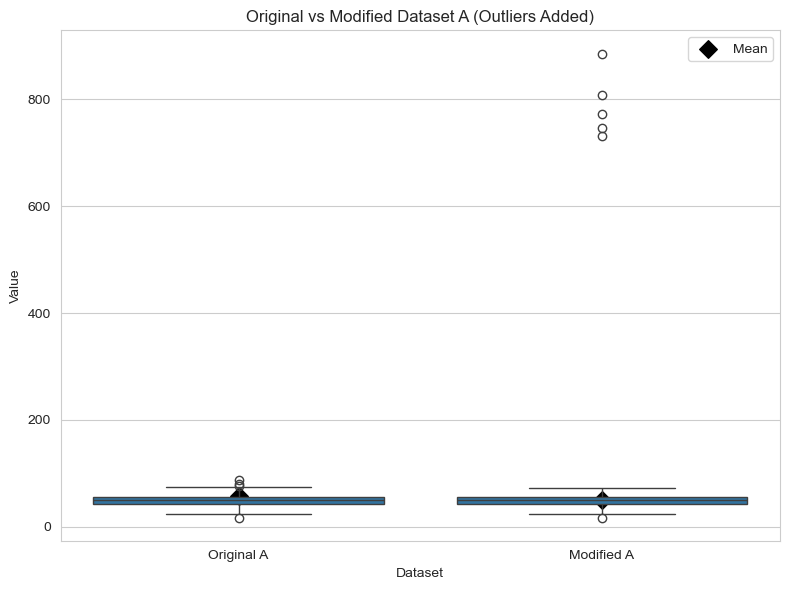

'\nThe mean, standard deviation, variance, skewness, and kurtosis changed the most after adding outliers. The median and IQR were more robust and stayed almost the same\n\nI would choose the median as the “typical” value for the modified dataset because it is not affected much by extreme outliers, while the mean is pulled strongly upward\n'

In [5]:
A_mod = A.copy()
largest_idx = np.argsort(A_mod)[-5:]
A_mod[largest_idx] = A_mod[largest_idx] * 10

summary_outliers = pd.DataFrame(
    [summarize(A), summarize(A_mod)],
    columns=["Mean","Median","Mode","Std Dev","Variance","IQR","Skewness","Kurtosis"],
    index=["Original A", "Modified A (Outliers)"]
)

summary_outliers = summary_outliers.round(2)
print(summary_outliers)

df_plot = pd.DataFrame({
    "Value": np.concatenate([A, A_mod]),
    "Dataset": ["Original A"] * n + ["Modified A"] * n
})

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_plot, x="Dataset", y="Value")

means = df_plot.groupby("Dataset")["Value"].mean()
for i, (label, mean_val) in enumerate(means.items()):
    plt.scatter(i, mean_val, color="black", marker="D", s=80, label="Mean" if i == 0 else "")

plt.title("Original vs Modified Dataset A (Outliers Added)")
plt.xlabel("Dataset")
plt.ylabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

"""
The mean, standard deviation, variance, skewness, and kurtosis changed the most after adding outliers. The median and IQR were more robust and stayed almost the same

I would choose the median as the “typical” value for the modified dataset because it is not affected much by extreme outliers, while the mean is pulled strongly upward
"""